In [20]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ler automaticamente o arquivo bruto Saturin (.csv) disponível no workspace

In [21]:
from pathlib import Path

candidate_files = [
    "raw_data_saturin.csv",
    "raw_nir_data_Saturin.csv",
    "raw_nir_data_saturin.csv",
    "raw_nirr_data_Saturin.csv",
    "raw_mir_data_Saturin.csv",
    "raw_mir_data_saturin.csv",
]

raw_data_file = next((f for f in candidate_files if Path(f).exists()), None)
if raw_data_file is None:
    raise FileNotFoundError(
        "Nenhum arquivo bruto Saturin encontrado. Esperado um destes: " + ", ".join(candidate_files)
    )

encodings = ["utf-8", "utf-8-sig", "latin-1", "cp1252"]
last_error = None
for enc in encodings:
    try:
        df = pd.read_csv(raw_data_file, encoding=enc, low_memory=False)
        used_encoding = enc
        break
    except UnicodeDecodeError as err:
        last_error = err
else:
    raise UnicodeDecodeError(
        last_error.encoding,
        last_error.object,
        last_error.start,
        last_error.end,
        "Falha ao ler o CSV com os encodings testados: " + ", ".join(encodings),
    )

# Normaliza nomes comuns para manter compatibilidade com o restante do notebook.
rename_map = {
    "ID_Unico": "id",
    "Owner": "classe_minerais",
    "pH_H2O": "pH",
    "OM_gkg": "MO",
    "P_mgkg": "P",
    "K_mmolkg": "K",
    "Clay_gkg": "Argilo",
    "Silt_gkg": "silte",
    "C_gkg": "carbono",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

print(f"Arquivo carregado: {raw_data_file}")
print(f"Encoding usado: {used_encoding}")
print(f"Total de colunas: {len(df.columns)}")
print("Primeiras 25 colunas:", df.columns[:25].tolist())
print("Formato geral:", df.shape)

Arquivo carregado: raw_nir_data_Saturin.csv
Encoding usado: latin-1
Total de colunas: 2173
Primeiras 25 colunas: ['Unnamed: 0', 'id', 'classe_minerais', 'X', 'Y', 'Country', 'Upper_depth_cm', 'Lower_depth_cm', 'Sand_gkg', 'silte', 'Argilo', 'Density_kgdm3', 'carbono', 'MO', 'P', 'pH', 'Ca_mmolkg', 'Mg_mmolkg', 'K', 'CEC_Ph7_mmolkg', 'CEC_Efe_mmolkg', 'MacroN_g_kg', '350', '351', '352']
Formato geral: (40137, 2173)


In [22]:
# a) coordenadas geográficas (X, Y)
if not {"X", "Y"}.issubset(df.columns):
    raise KeyError("As colunas X e Y são obrigatórias para a análise espacial.")
coords = df[["X", "Y"]].copy()

# b) classe de minerais do solo (usa fallback se necessário)
class_col_candidates = ["classe_minerais", "classe_minerais_solo", "Owner", "Country"]
class_col = next((c for c in class_col_candidates if c in df.columns), None)
if class_col is None:
    classe_minerais = pd.Series(["SemClasse"] * len(df), index=df.index)
else:
    classe_minerais = df[class_col].astype(str).copy()

# c) variáveis não-espectrais (textura, químicas, etc.)
cols_textura_quim = [
    "Argilo", "silte", "area", "carbono", "pH", "MO", "P", "K"
]

# d) extrair bandas espectrais
cols_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
bands_by_prefix = [c for c in cols_numeric if str(c).startswith("banda_")]
bands_by_numeric_name = [c for c in df.columns if str(c).isdigit()]

if bands_by_prefix:
    cols_spectra_full = bands_by_prefix
elif bands_by_numeric_name:
    cols_spectra_full = bands_by_numeric_name
else:
    cols_to_remove = ["X", "Y", "id"] + cols_textura_quim
    cols_spectra_full = [c for c in cols_numeric if c not in cols_to_remove]

if not cols_spectra_full:
    raise ValueError("Nenhuma coluna espectral foi identificada no arquivo carregado.")

X = df[cols_spectra_full].copy()

print("Número de amostras:", X.shape[0])
print("Número de bandas NIR usadas:", X.shape[1])
print("Coluna de classe usada:", class_col if class_col else "SemClasse")
print("Classes de minerais únicas (até 10):", classe_minerais.unique()[:10])

Número de amostras: 40137
Número de bandas NIR usadas: 2151
Coluna de classe usada: classe_minerais
Classes de minerais únicas (até 10): ['Sabine Grunwald' 'Songchao Chen' 'Setyono Hari Adi' 'Nikolaos Tziolas'
 'Cecile Gomez' 'Asa Gholizadeh' 'Masakazu Kodaira' 'Sari Virgawati'
 'Mahamed Mahmoud' 'Ayoub Lazaar']


NaN encontrados nas bandas: 2089756 (preenchidos com mediana)
Após escalonamento, X_scaled shape: (40137, 2151)
Variância explicada por componente:
PC1: 0.860 (86.0%)
PC2: 0.075 (7.5%)
PC3: 0.031 (3.1%)
PC4: 0.013 (1.3%)
PC5: 0.007 (0.7%)
PC6: 0.006 (0.6%)


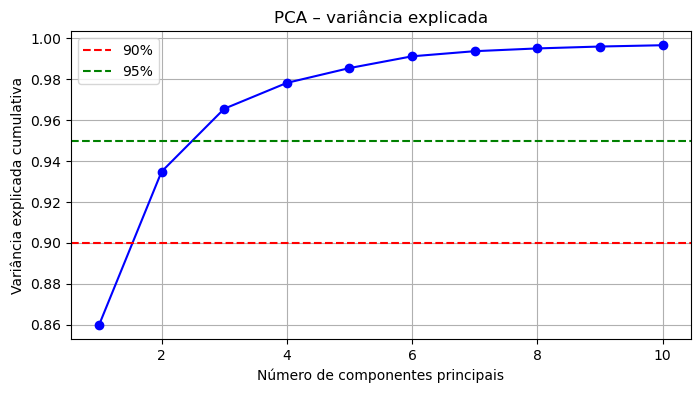

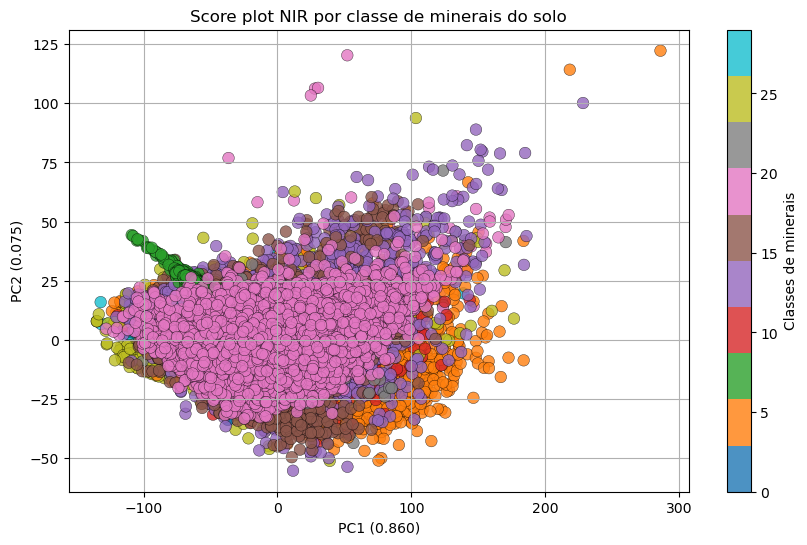

In [24]:
# 4. Escalar espectros NIR (StandardScaler)
# ------------------------------------------------
X_numeric = X.apply(pd.to_numeric, errors="coerce")
nan_total = int(X_numeric.isna().sum().sum())
if nan_total > 0:
    # Preenche NaN por mediana para permitir PCA em todo o conjunto.
    X_numeric = X_numeric.fillna(X_numeric.median())
    print(f"NaN encontrados nas bandas: {nan_total} (preenchidos com mediana)")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)                      # (n_amostras, n_bandas)

print("Após escalonamento, X_scaled shape:", X_scaled.shape)

# 5. PCA sobre as bandas NIR
# ------------------------------------------------
n_components = 10
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Variância explicada por componente:")
for i, v in enumerate(explained_variance[:6]):
    print(f"PC{i+1}: {v:.3f} ({v*100:.1f}%)")

# 5.1 Gráfico de variância cumulativa
plt.figure(figsize=(8, 4))
plt.plot(range(1, n_components + 1), cumulative_variance, "bo-", markersize=6)
plt.axhline(0.90, color="r", linestyle="--", label="90%")
plt.axhline(0.95, color="g", linestyle="--", label="95%")
plt.xlabel("Número de componentes principais")
plt.ylabel("Variância explicada cumulativa")
plt.title("PCA – variância explicada")
plt.grid(True)
plt.legend()
plt.show()

# 5.2 Score plot (PC1 vs PC2) colorido por classe de minerais
plt.figure(figsize=(10, 6))
cat_classe = pd.Categorical(classe_minerais).codes
scatter = plt.scatter(
    X_pca[:, 0],                                   # PC1
    X_pca[:, 1],                                   # PC2
    c=cat_classe,
    cmap="tab10",
    s=70,
    alpha=0.8,
    edgecolors="k",
    linewidth=0.3
)
plt.xlabel(f"PC1 ({explained_variance[0]:.3f})")
plt.ylabel(f"PC2 ({explained_variance[1]:.3f})")
plt.title("Score plot NIR por classe de minerais do solo")
plt.colorbar(scatter, label="Classes de minerais")
plt.grid(True)
plt.show()

Clusters encontrados: [0 1 2]


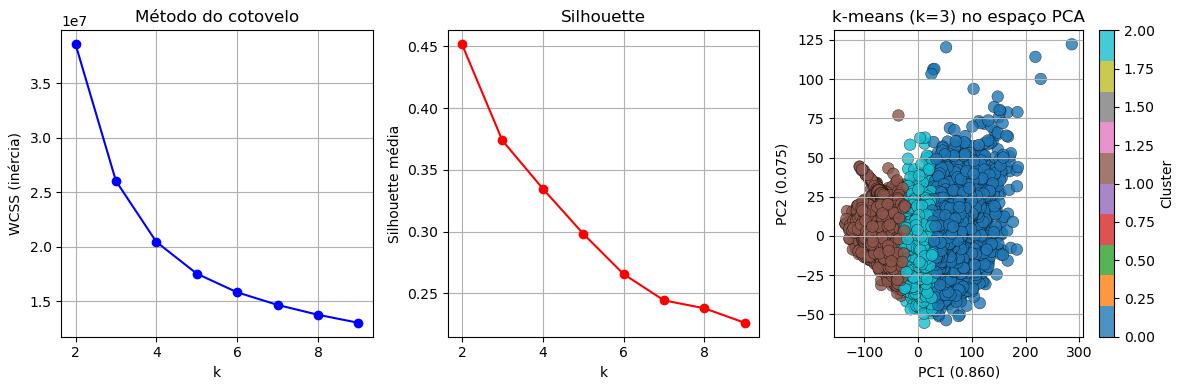

In [25]:
# 6. Procurar melhor número de clusters (k)
# ------------------------------------------------
k_range = range(2, 10)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

plt.figure(figsize=(12, 4))

# 6.1 Gráfico do cotovelo
plt.subplot(1, 3, 1)
plt.plot(k_range, inertias, "bo-", markersize=6)
plt.xlabel("k")
plt.ylabel("WCSS (inércia)")
plt.title("Método do cotovelo")
plt.grid(True)

# 6.2 Gráfico de silhueta
plt.subplot(1, 3, 2)
plt.plot(k_range, silhouettes, "ro-", markersize=6)
plt.xlabel("k")
plt.ylabel("Silhouette média")
plt.title("Silhouette")
plt.grid(True)

# 6.3 escolha de k (exemplo: k = 3) → ajuste você
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

print("Clusters encontrados:", np.unique(cluster_labels))

# 6.4 Score plot colorido por cluster
plt.subplot(1, 3, 3)
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=70,
    alpha=0.8,
    edgecolors="k",
    linewidth=0.3
)
plt.xlabel(f"PC1 ({explained_variance[0]:.3f})")
plt.ylabel(f"PC2 ({explained_variance[1]:.3f})")
plt.title(f"k‑means (k={k}) no espaço PCA")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)

plt.tight_layout()
plt.show()


Tabela cruzada cluster × classe de minerais do solo:
classe_minerais  Asa Gholizadeh  Ayoub Lazaar  Azizi  B. Minasny  Bhabani  \
cluster                                                                     
0                           123            44      3          37      645   
1                            17             8    211          93      273   
2                           197            48    118         112      410   
All                         337           100    332         242     1328   

classe_minerais  Brendam Malone  Cecile Gomez  Cesar Guerrero Maestre  \
cluster                                                                 
0                          1177            17                       0   
1                           398           136                    1362   
2                           507           175                      27   
All                        2082           328                    1389   

classe_minerais  Chang Kun  Dematte  ...  Ma

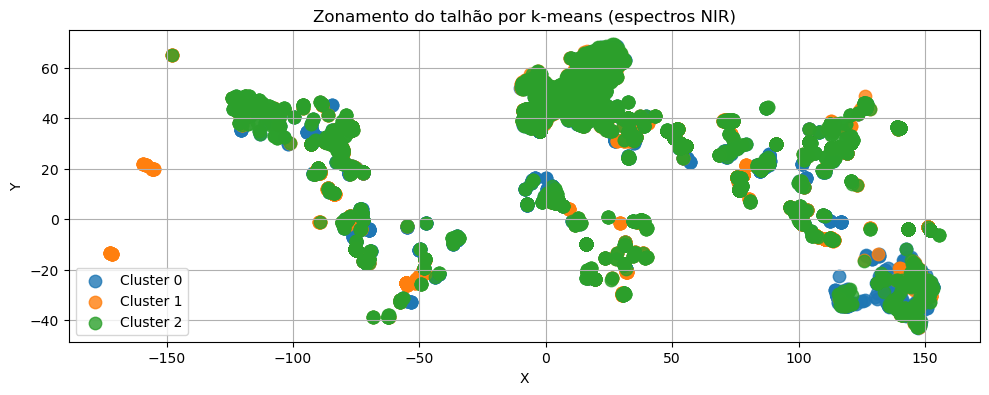

In [26]:
# 7. Montar DataFrame de análise com X, Y, classe e cluster
# ------------------------------------------------
df_ana = pd.DataFrame({
    "id": df["id"],
    "X": coords["X"],
    "Y": coords["Y"],
    "classe_minerais": classe_minerais,
    "cluster": cluster_labels
})

# 7.1 Tabela cruzada cluster × classe de minerais do solo
crosstab = pd.crosstab(df_ana["cluster"], df_ana["classe_minerais"], margins=True)
print("\nTabela cruzada cluster × classe de minerais do solo:")
print(crosstab)

# 7.2 Proporção de cada classe de minerais em cada cluster (normalizada)
cluster_summary = df_ana.groupby("cluster")["classe_minerais"].apply(
    lambda x: x.value_counts(normalize=True).round(3)
).unstack(fill_value=0)

print("\nProporção de cada classe de minerais por cluster (normalizada):")
print(cluster_summary)

# 7.3 Mapa de clusters no talhão (X, Y)
plt.figure(figsize=(10, 8))
for cluster in sorted(df_ana["cluster"].unique()):
    mask = df_ana["cluster"] == cluster
    plt.scatter(
        df_ana.loc[mask, "X"],
        df_ana.loc[mask, "Y"],
        label=f"Cluster {cluster}",
        alpha=0.8,
        s=80
    )
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Zonamento do talhão por k‑means (espectros NIR)")
plt.legend()
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

atributos_quimicos.csv não encontrado; usando colunas químicas do arquivo bruto.
Colunas de atributos químicos:
['id', 'pH', 'MO', 'P', 'K', 'Argilo', 'silte', 'carbono']
Formato de X_quimico: (40137, 8)
Exemplo de linhas após merge:
   id  cluster    pH  MO      P   K
0   1        1  8.10 NaN  14.36 NaN
1   2        1  8.00 NaN   3.35 NaN
2   3        1  8.00 NaN  22.12 NaN
3   4        1  8.00 NaN  20.44 NaN
4   5        1  7.91 NaN  15.07 NaN

Médias dos atributos químicos por cluster:
               pH         MO          P         K      Argilo       silte  \
cluster                                                                     
0        6.500696  15.849945  22.860529  4.278557  204.190388  409.628857   
1        6.116938  26.252408  36.200524  5.793344  226.391183  257.195792   
2        6.326561  30.026760  31.797816  5.039442  204.529556  362.161713   

           carbono  
cluster             
0        16.721189  
1        72.106425  
2        36.789741  


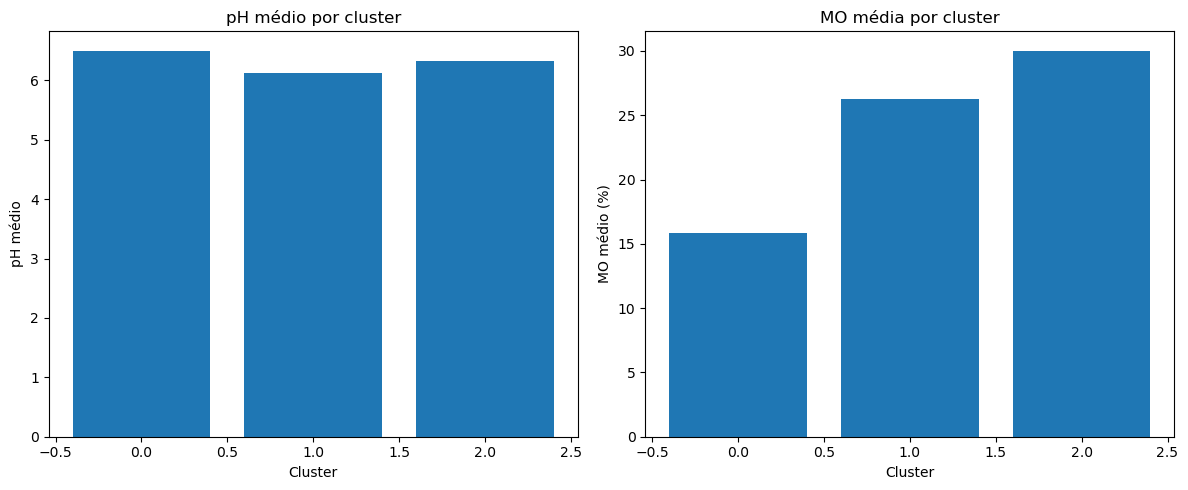

In [27]:
# 8. Ler arquivo de atributos químicos (pH, MO, P, K, minerais, etc.)
# ------------------------------------------------
from pathlib import Path

quimico_file = Path("atributos_quimicos.csv")
if quimico_file.exists():
    X_quimico = pd.read_csv(quimico_file)
    print(f"Arquivo de atributos químicos carregado: {quimico_file}")
else:
    # Fallback: usa as colunas químicas já existentes no arquivo bruto carregado.
    fallback_cols = ["pH", "MO", "P", "K", "Argilo", "silte", "area", "carbono"]
    available_fallback = [c for c in fallback_cols if c in df.columns]
    X_quimico = df[["id"] + available_fallback].copy()
    print("atributos_quimicos.csv não encontrado; usando colunas químicas do arquivo bruto.")

print("Colunas de atributos químicos:")
print(X_quimico.columns.tolist())
print("Formato de X_quimico:", X_quimico.shape)

# 8.1 garantir que X_quimico tem id para merge
if "id" not in X_quimico.columns:
    raise ValueError("X_quimico precisa ter coluna 'id' para realizar o merge com df_ana.")

# 8.2 merge pela coluna id
df_ana_full = df_ana.merge(X_quimico, on="id", how="left")

preview_cols = ["id", "cluster"] + [c for c in ["pH", "MO", "P", "K"] if c in df_ana_full.columns]
print("Exemplo de linhas após merge:")
print(df_ana_full[preview_cols].head())

# 9. Médias de atributos químicos por cluster
# ------------------------------------------------
# lista de colunas químicas/minerais que você quer analisar por cluster
quimico_cols = [
    "pH", "MO", "P", "K",
    "Argilo", "silte", "area", "carbono"
]
# ajuste aqui conforme suas colunas: argila, silt, carbono_organico, materia_org, CTC, Ca, Mg, etc.

# garanta que as colunas existem em df_ana_full
quimico_cols = [c for c in quimico_cols if c in df_ana_full.columns]
if not quimico_cols:
    raise ValueError("Nenhuma coluna química disponível para calcular médias por cluster.")

quimico_by_cluster = df_ana_full.groupby("cluster")[quimico_cols].mean()

print("\nMédias dos atributos químicos por cluster:")
print(quimico_by_cluster)

# 9.1 gráficos simples de pH e MO médios por cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if "pH" in quimico_by_cluster.columns:
    axes[0].bar(quimico_by_cluster.index, quimico_by_cluster["pH"])
    axes[0].set_title("pH médio por cluster")
else:
    axes[0].text(0.5, 0.5, "pH não disponível", ha="center", va="center")
    axes[0].set_title("pH médio por cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("pH médio")

mo_col = "MO" if "MO" in quimico_by_cluster.columns else "materia_org"
if mo_col in quimico_by_cluster.columns:
    axes[1].bar(quimico_by_cluster.index, quimico_by_cluster[mo_col])
    axes[1].set_ylabel("MO médio (%)")
    axes[1].set_title("MO média por cluster")
else:
    axes[1].text(0.5, 0.5, "MO não disponível", ha="center", va="center")
    axes[1].set_title("MO média por cluster")
    axes[1].set_ylabel("MO médio (%)")
axes[1].set_xlabel("Cluster")

plt.tight_layout()
plt.show()

In [28]:
print(f"Arquivo em uso: {raw_data_file}")
print(df.columns.tolist())

Arquivo em uso: raw_nir_data_Saturin.csv
['Unnamed: 0', 'id', 'classe_minerais', 'X', 'Y', 'Country', 'Upper_depth_cm', 'Lower_depth_cm', 'Sand_gkg', 'silte', 'Argilo', 'Density_kgdm3', 'carbono', 'MO', 'P', 'pH', 'Ca_mmolkg', 'Mg_mmolkg', 'K', 'CEC_Ph7_mmolkg', 'CEC_Efe_mmolkg', 'MacroN_g_kg', '350', '351', '352', '353', '354', '355', '356', '357', '358', '359', '360', '361', '362', '363', '364', '365', '366', '367', '368', '369', '370', '371', '372', '373', '374', '375', '376', '377', '378', '379', '380', '381', '382', '383', '384', '385', '386', '387', '388', '389', '390', '391', '392', '393', '394', '395', '396', '397', '398', '399', '400', '401', '402', '403', '404', '405', '406', '407', '408', '409', '410', '411', '412', '413', '414', '415', '416', '417', '418', '419', '420', '421', '422', '423', '424', '425', '426', '427', '428', '429', '430', '431', '432', '433', '434', '435', '436', '437', '438', '439', '440', '441', '442', '443', '444', '445', '446', '447', '448', '449', '450

## 10. Comportamento espectral do solo seco mineral (VIS-NIR-SWIR e mid-IR)

Este bloco combina os arquivos NIR e MIR para:
- calcular intensidade de reflectancia por faixa espectral;
- estimar intensidade de absorcao em bandas diagnosticas;
- visualizar o comportamento medio das curvas espectrais.

NIR carregado com encoding: latin-1 | MIR carregado com encoding: utf-8
Amostras integradas (NIR+MIR): 6230

Resumo das intensidades de reflectancia:
             mean       std       min       max
R_VIS    0.177292  0.083284  0.028527  0.764413
R_NIR    0.364755  0.118367  0.053821  0.920256
R_SWIR   0.410555  0.121709  0.099762  0.863193
R_MIDIR  0.131604  0.085915  0.012559  0.565038

Resumo das intensidades de absorcao:
              mean       std       min       max
ABS_1400  0.045828  0.048241 -0.066848  0.304133
ABS_1900  0.115166  0.078639 -0.027470  0.472966
ABS_2200  0.065204  0.081410 -0.118726  0.416533
ABS_3400  0.103424  0.051054 -0.271615  0.543942


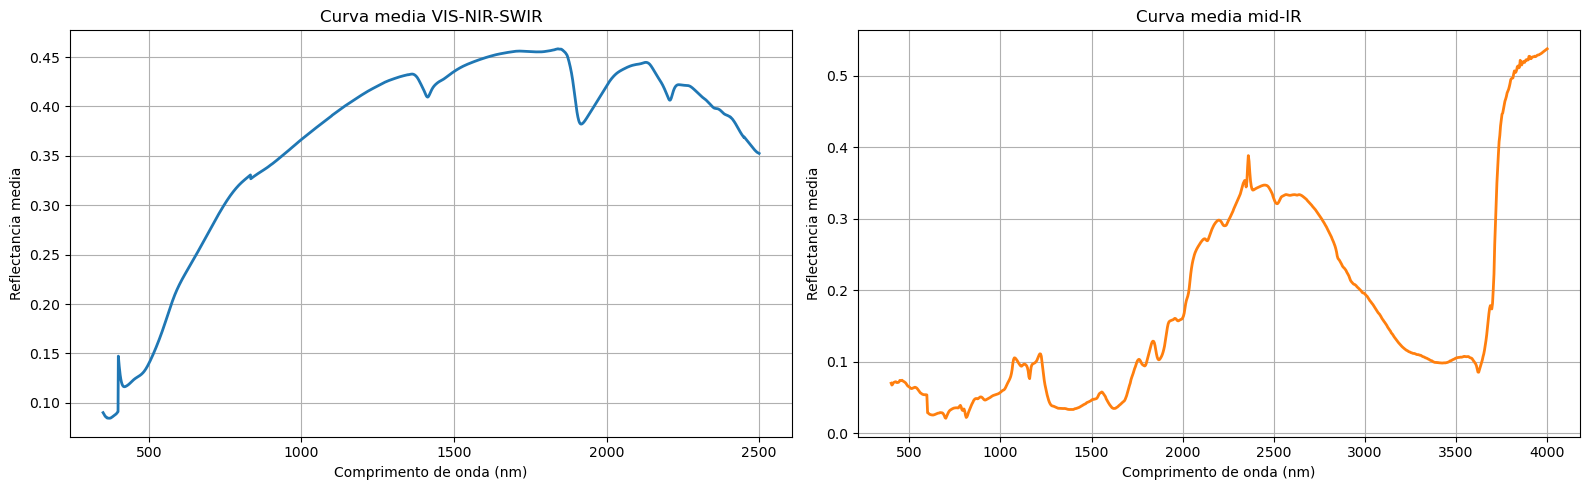

C:\Users\PC\AppData\Local\Temp\ipykernel_7104\4040430521.py:150: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=["VIS", "NIR", "SWIR", "mid-IR"], showfliers=False)


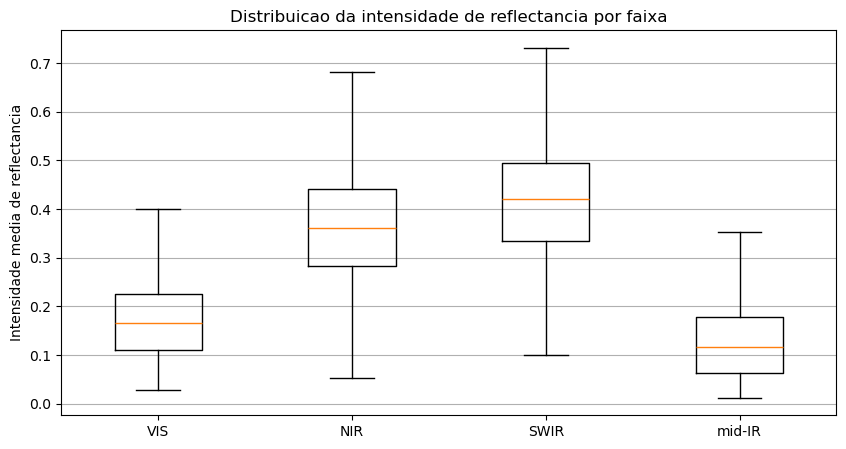

C:\Users\PC\AppData\Local\Temp\ipykernel_7104\4040430521.py:164: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(abs_plot, labels=["ABS1400", "ABS1900", "ABS2200", "ABS3400"], showfliers=False)


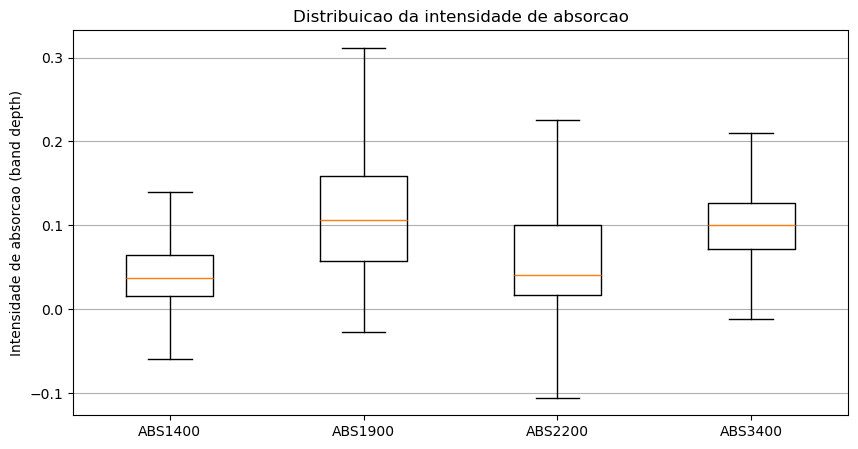

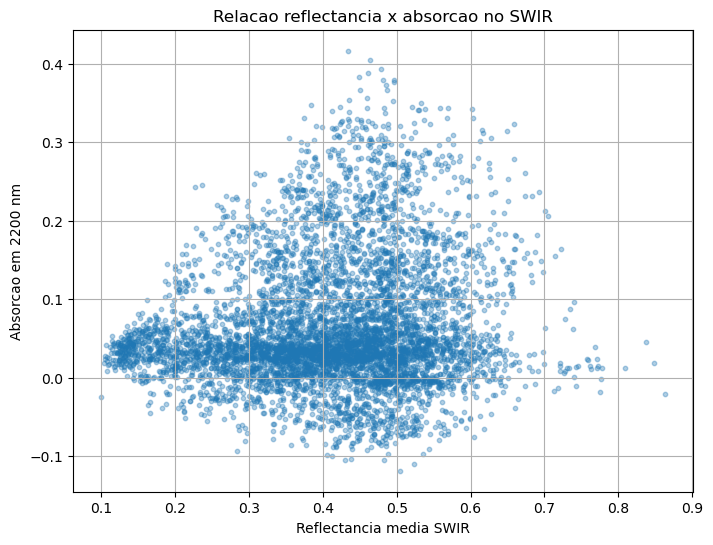

In [29]:
from pathlib import Path

# Arquivos espectrais
nir_file = Path("raw_nir_data_Saturin.csv")
mir_file = Path("raw_mir_data_Saturin.csv")

if not nir_file.exists() or not mir_file.exists():
    raise FileNotFoundError("Arquivos NIR/MIR nao encontrados no workspace.")

# Leitura com fallback de encoding
def read_csv_flexible(path):
    for enc in ["utf-8", "utf-8-sig", "latin-1", "cp1252"]:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=False), enc
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError("utf-8", b"", 0, 1, f"Falha ao ler {path.name}")

df_nir, enc_nir = read_csv_flexible(nir_file)
df_mir, enc_mir = read_csv_flexible(mir_file)

# Padroniza nomes minimos
rename_common = {
    "ID_Unico": "id",
    "Owner": "classe_minerais",
}
df_nir = df_nir.rename(columns={k: v for k, v in rename_common.items() if k in df_nir.columns})
df_mir = df_mir.rename(columns={k: v for k, v in rename_common.items() if k in df_mir.columns})

if "id" not in df_nir.columns or "id" not in df_mir.columns:
    raise KeyError("As tabelas NIR e MIR precisam conter a coluna id (ou ID_Unico).")

# Seleciona colunas espectrais numericas por nome de comprimento de onda
def spectral_cols(df):
    wl = [int(c) for c in df.columns if str(c).isdigit()]
    wl_sorted = sorted(wl)
    cols = [str(w) for w in wl_sorted]
    return cols, wl_sorted

nir_cols, nir_wl = spectral_cols(df_nir)
mir_cols, mir_wl = spectral_cols(df_mir)

if not nir_cols or not mir_cols:
    raise ValueError("Nao foi possivel identificar colunas espectrais numericas nos arquivos NIR/MIR.")

# Matrizes espectrais
nir_spec = df_nir[nir_cols].apply(pd.to_numeric, errors="coerce")
mir_spec = df_mir[mir_cols].apply(pd.to_numeric, errors="coerce")

# Preenche faltantes por mediana por banda
nir_spec = nir_spec.fillna(nir_spec.median())
mir_spec = mir_spec.fillna(mir_spec.median())

def cols_in_range(wl_list, lo, hi):
    return [str(w) for w in wl_list if lo <= w < hi]

# Faixas espectrais (nm)
vis_cols = cols_in_range(nir_wl, 400, 700)
nir_only_cols = cols_in_range(nir_wl, 700, 1300)
swir_cols = cols_in_range(nir_wl, 1300, 2500)
mid_ir_cols = cols_in_range(mir_wl, 2500, 4001)

if not vis_cols or not nir_only_cols or not swir_cols or not mid_ir_cols:
    raise ValueError("Uma ou mais faixas espectrais (VIS/NIR/SWIR/mid-IR) ficaram sem colunas.")

# Intensidade media de reflectancia por amostra
beh_nir = pd.DataFrame({
    "id": df_nir["id"],
    "classe_minerais": df_nir["classe_minerais"] if "classe_minerais" in df_nir.columns else "SemClasse",
    "R_VIS": nir_spec[vis_cols].mean(axis=1),
    "R_NIR": nir_spec[nir_only_cols].mean(axis=1),
    "R_SWIR": nir_spec[swir_cols].mean(axis=1),
})
beh_mir = pd.DataFrame({
    "id": df_mir["id"],
    "R_MIDIR": mir_spec[mid_ir_cols].mean(axis=1),
})

beh = beh_nir.merge(beh_mir, on="id", how="inner")

# Intensidade de absorcao (band depth simplificado)
def nearest_wl(available, target):
    return min(available, key=lambda x: abs(x - target))

def band_depth(spec_df, wl_available, center, left, right):
    c = str(nearest_wl(wl_available, center))
    l = str(nearest_wl(wl_available, left))
    r = str(nearest_wl(wl_available, right))
    cont = (spec_df[l] + spec_df[r]) / 2.0
    depth = 1.0 - (spec_df[c] / cont.replace(0, np.nan))
    return depth.fillna(0)

abs_1400 = band_depth(nir_spec, nir_wl, center=1400, left=1300, right=1500)
abs_1900 = band_depth(nir_spec, nir_wl, center=1900, left=1800, right=2000)
abs_2200 = band_depth(nir_spec, nir_wl, center=2200, left=2100, right=2300)
abs_3400 = band_depth(mir_spec, mir_wl, center=3400, left=3300, right=3500)

abs_df = pd.DataFrame({
    "id": df_nir["id"],
    "ABS_1400": abs_1400,
    "ABS_1900": abs_1900,
    "ABS_2200": abs_2200,
}).merge(
    pd.DataFrame({"id": df_mir["id"], "ABS_3400": abs_3400}),
    on="id",
    how="inner",
)

beh_full = beh.merge(abs_df, on="id", how="inner")

# Classes de intensidade de reflectancia (tercis)
for col in ["R_VIS", "R_NIR", "R_SWIR", "R_MIDIR"]:
    beh_full[f"INT_{col}"] = pd.qcut(beh_full[col], q=3, labels=["Baixa", "Media", "Alta"], duplicates="drop")

print(f"NIR carregado com encoding: {enc_nir} | MIR carregado com encoding: {enc_mir}")
print("Amostras integradas (NIR+MIR):", beh_full.shape[0])
print("\nResumo das intensidades de reflectancia:")
print(beh_full[["R_VIS", "R_NIR", "R_SWIR", "R_MIDIR"]].describe().T[["mean", "std", "min", "max"]])
print("\nResumo das intensidades de absorcao:")
print(beh_full[["ABS_1400", "ABS_1900", "ABS_2200", "ABS_3400"]].describe().T[["mean", "std", "min", "max"]])

# Visualizacoes
sample_idx_nir = np.random.RandomState(42).choice(len(nir_spec), size=min(3000, len(nir_spec)), replace=False)
sample_idx_mir = np.random.RandomState(42).choice(len(mir_spec), size=min(3000, len(mir_spec)), replace=False)

# Curvas medias VIS-NIR-SWIR e mid-IR
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(nir_wl, nir_spec.iloc[sample_idx_nir].mean(axis=0).values, color="tab:blue", lw=2)
ax[0].set_title("Curva media VIS-NIR-SWIR")
ax[0].set_xlabel("Comprimento de onda (nm)")
ax[0].set_ylabel("Reflectancia media")
ax[0].grid(True)

ax[1].plot(mir_wl, mir_spec.iloc[sample_idx_mir].mean(axis=0).values, color="tab:orange", lw=2)
ax[1].set_title("Curva media mid-IR")
ax[1].set_xlabel("Comprimento de onda (nm)")
ax[1].set_ylabel("Reflectancia media")
ax[1].grid(True)
plt.tight_layout()
plt.show()

# Intensidades de reflectancia por faixa
plt.figure(figsize=(10, 5))
box_data = [
    beh_full["R_VIS"],
    beh_full["R_NIR"],
    beh_full["R_SWIR"],
    beh_full["R_MIDIR"],
]
plt.boxplot(box_data, labels=["VIS", "NIR", "SWIR", "mid-IR"], showfliers=False)
plt.ylabel("Intensidade media de reflectancia")
plt.title("Distribuicao da intensidade de reflectancia por faixa")
plt.grid(True, axis="y")
plt.show()

# Intensidades de absorcao
plt.figure(figsize=(10, 5))
abs_plot = [
    beh_full["ABS_1400"],
    beh_full["ABS_1900"],
    beh_full["ABS_2200"],
    beh_full["ABS_3400"],
]
plt.boxplot(abs_plot, labels=["ABS1400", "ABS1900", "ABS2200", "ABS3400"], showfliers=False)
plt.ylabel("Intensidade de absorcao (band depth)")
plt.title("Distribuicao da intensidade de absorcao")
plt.grid(True, axis="y")
plt.show()

# Relacao entre reflectancia SWIR e absorcao 2200 nm
plot_df = beh_full.sample(min(8000, len(beh_full)), random_state=42)
plt.figure(figsize=(8, 6))
plt.scatter(plot_df["R_SWIR"], plot_df["ABS_2200"], s=10, alpha=0.35)
plt.xlabel("Reflectancia media SWIR")
plt.ylabel("Absorcao em 2200 nm")
plt.title("Relacao reflectancia x absorcao no SWIR")
plt.grid(True)
plt.show()